In [133]:
import scipy.optimize as sci_opt
import requests
import pandas as pd
from pathlib import Path
import numpy as np

In [ ]:

API_KEY = "38b180a56f95c90b99575163922a8e670f46"
BASE_FOLDER = Path(r"C:\Usmgo-data\data-sets")


def get_or_create_dataset(assets, start_date="2000-01-01", end_date="2026-01-01", api_key=API_KEY):
    # Normalizar assets
    assets = [asset.upper().strip() for asset in assets]

    # Crear nombre consistente del archivo
    # sorted() hace que ['KO','WMT','VOO'] y ['VOO','KO','WMT'] generen el mismo nombre
    file_name = "_".join(sorted(assets)) + ".csv"
    file_path = BASE_FOLDER / file_name

    # Crear carpeta si no existe
    BASE_FOLDER.mkdir(parents=True, exist_ok=True)

    # Si ya existe, cargarlo
    if file_path.exists():
        print(f"Archivo encontrado: {file_path}")
        price_data_frame = pd.read_csv(file_path, index_col=0, parse_dates=True)
        return price_data_frame

    # Si no existe, descargarlo
    print(f"Archivo no encontrado. Descargando datos para: {assets}")

    all_data = {}

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Token {api_key}"
    }

    for asset in assets:
        url = f"https://api.tiingo.com/tiingo/daily/{asset}/prices?startDate={start_date}&endDate={end_date}"

        response = requests.get(url, headers=headers)
        response.raise_for_status()

        data = response.json()

        if not data:
            raise ValueError(f"No se encontraron datos para {asset}")

        df = pd.DataFrame(data)
        df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
        df.set_index("date", inplace=True)

        all_data[asset] = df["adjClose"]

    # Unir todos los precios de cierre en un solo DataFrame
    price_data_frame_full = pd.DataFrame(all_data)

    # Guardar CSV
    price_data_frame_full.to_csv(file_path)
    print(f"Archivo guardado en: {file_path}")

    return price_data_frame_full


In [135]:
assets = ["XLF", "XLK", "XLE", "GLD", "TLT", "VNQ", "SPY", "XLP", "XLU"]

price_data_frame_full = get_or_create_dataset(assets)     # ← All the data

# Train-Test     
# ── Nuevo Escenario ──────────────────────────────────────────
price_data_frame = price_data_frame_full.loc["2004-01-01":"2008-08-31"].dropna().copy()
price_test = price_data_frame_full.loc["2008-09-01":"2009-06-30"].dropna().copy()


print(price_data_frame.head())
print(price_data_frame.tail())

Archivo no encontrado. Descargando datos para: ['XLF', 'XLK', 'XLE', 'GLD', 'TLT', 'VNQ', 'SPY', 'XLP', 'XLU']
Archivo guardado en: C:\Users\carle\Documents\Portafolio Optimization\Tiingo-data\data-sets\GLD_SPY_TLT_VNQ_XLE_XLF_XLK_XLP_XLU.csv
                  XLF       XLK        XLE    GLD        TLT        VNQ  \
date                                                                      
2004-11-18  15.615140  7.984253   9.792133  44.38  44.236181  21.425017   
2004-11-19  15.415149  7.860785   9.909257  44.78  43.883166  21.203570   
2004-11-22  15.504619  7.872009  10.067239  44.95  44.111880  21.349883   
2004-11-23  15.541459  7.838336  10.129887  44.75  44.166572  21.440835   
2004-11-24  15.604614  7.901941  10.214325  45.05  44.166572  21.812550   

                  SPY        XLP       XLU  
date                                        
2004-11-18  79.895936  13.169754  6.528533  
2004-11-19  79.007754  13.025979  6.504707  
2004-11-22  79.384562  13.112244  6.607162  
2004-1

In [136]:
# Calculate the log return + 1      Ex. 1.054
log_return = np.log(1 +price_data_frame.pct_change()).dropna()

# Check the number of assets
num_of_assets = len(assets)

# Risk free
risk_free = 0

# =============================================
# Monte Carlo
# =============================================

# Define the number of simulations (portafolios)
num_of_portafolios = 10000

# Create array for each weights of each simulation
all_weights = np.zeros((num_of_portafolios, num_of_assets))

# Array for retruns of each simulation
ret_arr = np.zeros(num_of_portafolios)

# Array for volatility
vol_arr = np.zeros(num_of_portafolios)

# Sharpe Ratios
sharpe_arr = np.zeros(num_of_portafolios)

# Simulation
for ind in range(num_of_portafolios):
    # Calculate weights and sum of weights = 1
    weights = np.array(np.random.random(num_of_assets))
    weights = weights / np.sum(weights)

    # Save in weights array
    all_weights[ind,:] = weights

    # Calculate the expected LOG returns
    ret_arr[ind] = np.sum((log_return.mean()*weights)*252)   # *252 Anual

    # Calculate volatility
    vol_arr[ind] = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov()*252, weights))   #  [ weights.T * Cov(Matrix) * weithts ] = (1,1)
    )

    # Calculate the sharp ratio
    sharpe_arr[ind] = (ret_arr[ind] - risk_free) / vol_arr[ind]

# Let's create our "Master Data Frame"
simulations_df = pd.DataFrame({
    'Returns': ret_arr,
    'Volatility': vol_arr,
    'Sharpe Ratio': sharpe_arr,
    'Portfolio Weights': list(all_weights)
})


# Monte Carlo results
max_sharpe_ratio_mc = simulations_df.loc[simulations_df['Sharpe Ratio'].idxmax()]
min_volatility_mc = simulations_df.loc[simulations_df['Volatility'].idxmin()]

# Extract Monte Carlo weights
mc_max_sharpe_weights_df = pd.DataFrame({
    'Symbol': assets,
    'Weight': max_sharpe_ratio_mc['Portfolio Weights']
})

mc_min_vol_weights_df = pd.DataFrame({
    'Symbol': assets,
    'Weight': min_volatility_mc['Portfolio Weights']
})


# =====================================================================================
# OPTIMIZATION
# =====================================================================================

# With a given set of weights, the function returns the portfolio expected return,
# volatility (desv st), and Sharpe ratio.
def get_metrics(weights: list) -> np.array:

    # Convert to a numpy array
    weights = np.array(weights)

    # Calculate annualized return
    ret = np.sum(log_return.mean() * weights) * 252

    # Calculate the volatility
    vol = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov() * 252, weights))
    )

    # Calculate the Sharpe ratio, assuming 0 risk free
    sr = (ret - risk_free) / vol

    return np.array([ret, vol, sr])


# We have to negativize the Sharpe ratio, in order to minimize
def grab_negative_sharpe(weights: list) -> np.array:
    return get_metrics(weights)[2] * (-1)


def grab_volatility(weights: list) -> np.array:
    return get_metrics(weights)[1]


# Scipy requires equality constraints (type='eq') to return 0
# We need the weights to sum to 1, so we return sum - 1
def check_sum(weights: list) -> float:
    return np.sum(weights) - 1


# Sequence of (min, max) pairs for each element in x
bounds = tuple((0, 1) for symbol in range(num_of_assets))

# Constraint weights = 100%
constraints = ({'type': 'eq', 'fun': check_sum})

# Initial guess: equal distribution
init_guess = num_of_assets * [1 / num_of_assets]

# Perform the operation to maximize Sharpe ratio
optimized_sharpe = sci_opt.minimize(
    grab_negative_sharpe,
    init_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Perform the operation to minimize volatility
optimized_volatility = sci_opt.minimize(
    grab_volatility,
    init_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Extract optimized weights
opt_sharpe_weights = optimized_sharpe.x
opt_vol_weights = optimized_volatility.x

# Extract optimized metrics
opt_sharpe_metrics = get_metrics(opt_sharpe_weights)
opt_vol_metrics = get_metrics(opt_vol_weights)

# Put optimized weights into DataFrames
opt_max_sharpe_weights_df = pd.DataFrame({
    'Symbol': assets,
    'Weight': opt_sharpe_weights
})

opt_min_vol_weights_df = pd.DataFrame({
    'Symbol': assets,
    'Weight': opt_vol_weights
})

# Put optimized metrics into DataFrames
opt_max_sharpe_metrics_df = pd.DataFrame({
    'Returns': [opt_sharpe_metrics[0]],
    'Volatility': [opt_sharpe_metrics[1]],
    'Sharpe Ratio': [opt_sharpe_metrics[2]]
})

opt_min_vol_metrics_df = pd.DataFrame({
    'Returns': [opt_vol_metrics[0]],
    'Volatility': [opt_vol_metrics[1]],
    'Sharpe Ratio': [opt_vol_metrics[2]]
})


# =====================================================================================
# DISPLAY RESULTS
# =====================================================================================

from tabulate import tabulate

def fmt(val):
    return f"{val:.6f}"

def print_section(title, mc_row, opt_metrics, mc_weights_df, opt_weights_df):
    width = 74
    print()
    print('╔' + '═' * width + '╗')
    print('║' + title.center(width) + '║')
    print('╠' + '═' * width + '╣')

    # Metrics table
    metrics_data = [
        ['Monte Carlo',  fmt(mc_row['Returns']),  fmt(mc_row['Volatility']),  fmt(mc_row['Sharpe Ratio'])],
        ['Optimization', fmt(opt_metrics[0]),      fmt(opt_metrics[1]),        fmt(opt_metrics[2])],
    ]
    metrics_table = tabulate(
        metrics_data,
        headers=['Method', 'Returns', 'Volatility', 'Sharpe Ratio'],
        tablefmt='simple',
        colalign=('left', 'right', 'right', 'right')
    )
    for line in metrics_table.splitlines():
        print('║  ' + line.ljust(width - 2) + '║')

    print('╠' + '═' * width + '╣')
    print('║' + ' WEIGHTS'.ljust(width) + '║')
    print('╠' + '═' * width + '╣')

    # Weights table — merge MC and OPT side by side
    weights_data = []
    for sym, w_mc, w_opt in zip(mc_weights_df['Symbol'], mc_weights_df['Weight'], opt_weights_df['Weight']):
        weights_data.append([sym, fmt(w_mc), fmt(w_opt)])

    weights_table = tabulate(
        weights_data,
        headers=['Symbol', 'Monte Carlo', 'Optimization'],
        tablefmt='simple',
        colalign=('left', 'right', 'right')
    )
    for line in weights_table.splitlines():
        print('║  ' + line.ljust(width - 2) + '║')

    print('╚' + '═' * width + '╝')


# --- MAX SHARPE RATIO ---
print_section(
    title='MAX SHARPE RATIO',
    mc_row=max_sharpe_ratio_mc,
    opt_metrics=opt_sharpe_metrics,
    mc_weights_df=mc_max_sharpe_weights_df,
    opt_weights_df=opt_max_sharpe_weights_df
)

# --- MIN VOLATILITY ---
print_section(
    title='MIN VOLATILITY',
    mc_row=min_volatility_mc,
    opt_metrics=opt_vol_metrics,
    mc_weights_df=mc_min_vol_weights_df,
    opt_weights_df=opt_min_vol_weights_df
)


╔══════════════════════════════════════════════════════════════════════════╗
║                             MAX SHARPE RATIO                             ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Method          Returns    Volatility    Sharpe Ratio                   ║
║  ------------  ---------  ------------  --------------                   ║
║  Monte Carlo    0.111862      0.092412         1.21047                   ║
║  Optimization   0.094587       0.06753         1.40067                   ║
╠══════════════════════════════════════════════════════════════════════════╣
║ WEIGHTS                                                                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Symbol      Monte Carlo    Optimization                                 ║
║  --------  -------------  --------------                                 ║
║  XLF            0.010658               0                                 


╔══════════════════════════════════════════════════════════════════════════╗
║                       BACKTEST — MAX SHARPE RATIO                        ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Metric                 Value                                            ║
║  -----------------  ---------                                            ║
║  Total Return          -2.11%                                            ║
║  Annual Return         -2.56%                                            ║
║  Annual Volatility     16.13%                                            ║
║  Sharpe Ratio         -0.1585                                            ║
║  Max Drawdown         -12.65%                                            ║
║  Final Capital      $9,788.59                                            ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Symbol      Weight                                                      

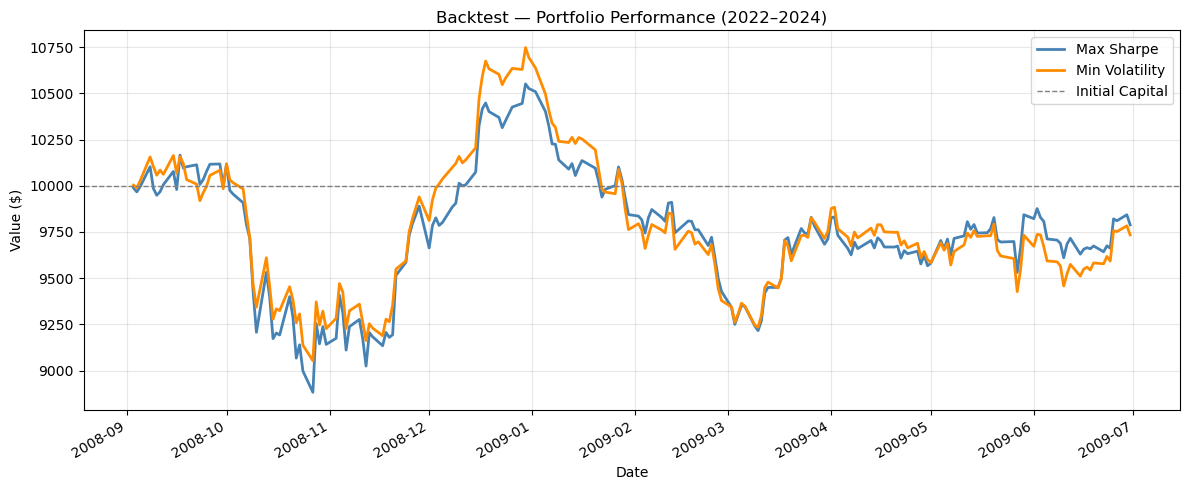

In [137]:
# ========================================================
# Backtesting
# ========================================================

def run_backtest(price_test, weights, label, initial_capital = 10000):

    # Check daily return, % of change each day
    daily_return = price_test.pct_change()
    # Clean NaN of the first line 
    daily_return = daily_return.dropna()

    # We can see this as a matriz multiplicacion (nx3)x(3x1), so we have (nx1) for each asset.
    portfolio_daily_return = (daily_return * weights).sum(axis = 1)
    portfolio_value = initial_capital * (1 + portfolio_daily_return).cumprod()

      # Métricas reales
    total_return     = (portfolio_value.iloc[-1] / initial_capital) - 1
    annual_return    = (1 + total_return) ** (252 / len(portfolio_value)) - 1
    annual_vol       = portfolio_daily_return.std() * np.sqrt(252)
    sharpe           = annual_return / annual_vol

    # Max Drawdown
    rolling_max      = portfolio_value.cummax()
    drawdown         = (portfolio_value - rolling_max) / rolling_max
    max_drawdown     = drawdown.min()

    # Result
    result_df = pd.DataFrame({'Portfolio Value': portfolio_value})

    # Print
    width = 74
    print()
    print('╔' + '═' * width + '╗')
    print('║' + f'BACKTEST — {label}'.center(width) + '║')
    print('╠' + '═' * width + '╣')

    metrics_data = [
        ['Total Return',      f"{total_return*100:.2f}%"],
        ['Annual Return',     f"{annual_return*100:.2f}%"],
        ['Annual Volatility', f"{annual_vol*100:.2f}%"],
        ['Sharpe Ratio',      f"{sharpe:.4f}"],
        ['Max Drawdown',      f"{max_drawdown*100:.2f}%"],
        ['Final Capital',     f"${portfolio_value.iloc[-1]:,.2f}"],
    ]

    from tabulate import tabulate
    table = tabulate(metrics_data, headers=['Metric', 'Value'],
                     tablefmt='simple', colalign=('left', 'right'))
    for line in table.splitlines():
        print('║  ' + line.ljust(width - 2) + '║')

    print('╠' + '═' * width + '╣')

    weights_data = [[sym, f"{w*100:.2f}%"] for sym, w in zip(assets, weights)]
    w_table = tabulate(weights_data, headers=['Symbol', 'Weight'],
                       tablefmt='simple', colalign=('left', 'right'))
    for line in w_table.splitlines():
        print('║  ' + line.ljust(width - 2) + '║')

    print('╚' + '═' * width + '╝')

    return result_df

# --- Run backtests ---

bt_max_sharpe = run_backtest(price_test, opt_sharpe_weights, label="MAX SHARPE RATIO")
bt_min_vol    = run_backtest(price_test, opt_vol_weights,    label="MIN VOLATILITY")


# --- Visual comparison ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

bt_max_sharpe['Portfolio Value'].plot(ax=ax, label='Max Sharpe',    color='steelblue',  linewidth=2)
bt_min_vol['Portfolio Value'].plot(ax=ax,    label='Min Volatility', color='darkorange', linewidth=2)

ax.axhline(10_000, color='gray', linestyle='--', linewidth=1, label='Initial Capital')
ax.set_title('Backtest — Portfolio Performance (2022–2024)')
ax.set_ylabel('Value ($)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()